# ERP CORE P3 RT-Sorted Examples

This notebook loads the processed ERP CORE P3 dataset from `real_data_sets/erp_core_p3`
and builds RT-sorted ERP images with the intended preprocessing order:

- filter to `rare` correct trials (the P3 parent condition at `Pz`)
- sort trials by `reaction_time_ms`
- z-score per timepoint across trials
- Gaussian low-pass filtering with the repo processing default `LOWPASS_FACTOR = 0.75`
- resize to `64x64`

Notes:

- `MNE` reads EEGLAB amplitudes in volts; the waveform sanity checks below convert averages to `uV`
- the matrix is transposed before `heatmap!` so the horizontal axis is time and the vertical axis is RT-sorted trial rank

Primary references used for the dataset conversion and import:

- ERP CORE P3 OSF component: <https://osf.io/etdkz/>
- ERP CORE P3 processing scripts: <https://github.com/lucklab/ERP_CORE/tree/master/P3>
- MNE EEGLAB epoch reader docs: <https://mne.tools/stable/generated/mne.read_epochs_eeglab.html>
- EEGLAB `erpimage` docs: <https://eeglab.org/tutorials/08_Plot_data/Plotting_ERP_images.html>


In [1]:
import Pkg

ENV["JULIA_PKG_PRECOMPILE_AUTO"] = "0"
ENV["JULIA_NUM_PRECOMPILE_TASKS"] = "1"

Pkg.activate(".")

using CSV, DataFrames, HDF5, JSON3, PrettyTables, Statistics, Printf
using ImageFiltering: imfilter
using Images: imresize
using CairoMakie

include(joinpath(pwd(), "..", "utils", "erp_image_utils.jl"))
using .ERPImageUtils: gaussian_kernel, zscore_timepoints, clipped_color_stats_quantile_zero_ticks


  Activating project at `~/Dokumente/BA2/notebooks/model_test`


In [2]:
const DATASET_DIR = joinpath(pwd(), "real_data_sets", "erp_core_p3")
const H5_PATH = joinpath(DATASET_DIR, "epochs.hdf5")
const EVENTS_PATH = joinpath(DATASET_DIR, "events_rt.csv")
const METADATA_PATH = joinpath(DATASET_DIR, "metadata.json")

const SAMPLE_SUBJECTS = nothing
const TARGET_CHANNEL = "Pz"
const CONDITION_FILTER = "rare"
const TARGET_SIZE = (64, 64)
const LOWPASS_FACTOR = 0.75f0
const LOWPASS_KERNEL_SIZE = (21, 21)
const FILTER_BORDER = "reflect"
const SORT_COL = :reaction_time_ms
const P300_WINDOW_MS = (300f0, 600f0)

for p in [H5_PATH, EVENTS_PATH, METADATA_PATH]
    @assert isfile(p) "File not found: $p"
end

println("DATASET_DIR      = ", DATASET_DIR)
println("H5_PATH          = ", H5_PATH)
println("EVENTS_PATH      = ", EVENTS_PATH)
println("TARGET_CHANNEL   = ", TARGET_CHANNEL)
println("CONDITION_FILTER = ", CONDITION_FILTER)
println("TARGET_SIZE      = ", TARGET_SIZE)
println("LOWPASS_FACTOR   = ", LOWPASS_FACTOR)
println("P300_WINDOW_MS   = ", P300_WINDOW_MS)


DATASET_DIR      = /home/benjamin/Dokumente/BA2/notebooks/model_test/real_data_sets/erp_core_p3
H5_PATH          = /home/benjamin/Dokumente/BA2/notebooks/model_test/real_data_sets/erp_core_p3/epochs.hdf5
EVENTS_PATH      = /home/benjamin/Dokumente/BA2/notebooks/model_test/real_data_sets/erp_core_p3/events_rt.csv
TARGET_CHANNEL   = Pz
CONDITION_FILTER = rare
TARGET_SIZE      = (64, 64)
LOWPASS_FACTOR   = 0.75
P300_WINDOW_MS   = (300.0f0, 600.0f0)


In [3]:
metadata = JSON3.read(read(METADATA_PATH, String))
events_df = CSV.read(EVENTS_PATH, DataFrame)
filtered_events_df = events_df[events_df.condition .== CONDITION_FILTER, :]

function load_subject_data(path::AbstractString, subject_label::AbstractString)
    return h5open(path, "r") do f
        g = f["subjects"][subject_label]
        (
            epochs = read(g["epochs"]),
            times_s = Float32.(read(g["times_s"])),
            channel_names = String.(read(g["channel_names"])),
            source_set_relpath = read(HDF5.attributes(g)["source_set_relpath"]),
            source_eventlist_relpath = read(HDF5.attributes(g)["source_eventlist_relpath"]),
            sfreq_hz = Float64(read(HDF5.attributes(g)["sfreq_hz"])),
            n_channels = Int(read(HDF5.attributes(g)["n_channels"])),
            n_timepoints = Int(read(HDF5.attributes(g)["n_timepoints"])),
            n_trials = Int(read(HDF5.attributes(g)["n_trials"])),
        )
    end
end

condition_counts = combine(groupby(events_df, :condition), nrow => :n_trials_total)
subject_summary = combine(
    groupby(filtered_events_df, :subject_label),
    nrow => :n_trials,
    :reaction_time_ms => minimum => :rt_min_ms,
    :reaction_time_ms => maximum => :rt_max_ms,
    :reaction_time_ms => mean => :rt_mean_ms,
)

subject_summary.rt_min_ms = round.(subject_summary.rt_min_ms, digits = 2)
subject_summary.rt_max_ms = round.(subject_summary.rt_max_ms, digits = 2)
subject_summary.rt_mean_ms = round.(subject_summary.rt_mean_ms, digits = 2)

println("Metadata source_component  = ", String(metadata.source_component))
println("Metadata processing        = ", String(metadata.source_processing_scripts))
println("Metadata reader_docs       = ", String(metadata.reader_docs))
println("Subjects in events CSV     = ", length(unique(events_df.subject_label)))
println("Rows in events CSV         = ", nrow(events_df))
println("Rows in filtered CSV view  = ", nrow(filtered_events_df))
println("Condition counts:")
pretty_table(condition_counts)
println("Rare-trial summary (first 10 rows):")
pretty_table(first(subject_summary, 10))


Metadata source_component  = https://osf.io/etdkz/
Metadata processing        = https://github.com/lucklab/ERP_CORE/tree/master/P3
Metadata reader_docs       = https://mne.tools/stable/generated/mne.read_epochs_eeglab.html
Subjects in events CSV     = 40
Rows in events CSV         = 7448
Rows in filtered CSV view  = 1340
Condition counts:
┌───────────┬────────────────┐
│ condition │ n_trials_total │
│  String15 │          Int64 │
├───────────┼────────────────┤
│      rare │           1340 │
│  frequent │           6108 │
└───────────┴────────────────┘
Rare-trial summary (first 10 rows):
┌───────────────┬──────────┬───────────┬───────────┬────────────┐
│ subject_label │ n_trials │ rt_min_ms │ rt_max_ms │ rt_mean_ms │
│       String7 │    Int64 │   Float64 │   Float64 │    Float64 │
├───────────────┼──────────┼───────────┼───────────┼────────────┤
│       sub-001 │       35 │    422.85 │     700.2 │     560.35 │
│       sub-002 │       39 │    399.41 │    747.07 │     520.23 │
│       su

In [4]:
function select_subject_events(df::DataFrame, subject_label::AbstractString;
                               condition_filter::Union{Nothing, String} = CONDITION_FILTER)
    rows = df[df.subject_label .== subject_label, :]
    if condition_filter !== nothing
        rows = rows[rows.condition .== condition_filter, :]
    end
    sort!(rows, :epoch_index)
    @assert !isempty(rows) "No events left for $(subject_label) after filtering"
    return rows
end

function peak_in_window(avg_uv::AbstractVector, times_ms::AbstractVector;
                        window_ms::Tuple{Float32, Float32} = P300_WINDOW_MS)
    win_idx = findall(t -> (window_ms[1] <= t <= window_ms[2]), times_ms)
    @assert !isempty(win_idx) "P300 window is empty"
    peak_idx = win_idx[argmax(avg_uv[win_idx])]
    return Float32(times_ms[peak_idx]), Float32(avg_uv[peak_idx])
end

function build_rt_sorted_erp_image(subject_label::AbstractString, channel_name::String, events_df::DataFrame;
                                   condition_filter::Union{Nothing, String} = CONDITION_FILTER,
                                   target_size::Tuple{Int, Int} = TARGET_SIZE,
                                   low_pass_factor::Float32 = LOWPASS_FACTOR)
    subj = load_subject_data(H5_PATH, subject_label)
    channel_idx = findfirst(==(channel_name), subj.channel_names)
    channel_idx === nothing && error("Channel $(channel_name) not found for $(subject_label)")

    subj_events = select_subject_events(events_df, subject_label; condition_filter = condition_filter)
    rt_sorted = sort(subj_events, SORT_COL)
    epoch_indices = Int.(rt_sorted.epoch_index)

    post_idx = findall(t -> t >= 0f0, subj.times_s)
    @assert !isempty(post_idx) "No post-stimulus samples found for $(subject_label)"

    data_time_trial = Float32.(subj.epochs[channel_idx, post_idx, epoch_indices])
    data_z = zscore_timepoints(data_time_trial)
    img_trials_time = Float32.(permutedims(data_z, (2, 1)))

    kernel = gaussian_kernel(low_pass_factor, size(img_trials_time), target_size, LOWPASS_KERNEL_SIZE)
    img_filtered = Float32.(imfilter(img_trials_time, kernel, FILTER_BORDER))
    img_resized = Float32.(imresize(img_filtered, target_size))

    times_ms_full = Float32.(1000 .* subj.times_s)
    times_ms_post = Float32.(1000 .* subj.times_s[post_idx])
    avg_erp_uv = vec(1f6 .* mean(Float32.(subj.epochs[channel_idx, :, epoch_indices]), dims = 2))
    peak_ms, peak_uv = peak_in_window(avg_erp_uv, times_ms_full)

    return (
        subject_label = subject_label,
        channel_name = channel_name,
        condition = condition_filter === nothing ? "all" : condition_filter,
        img_filtered = img_filtered,
        img_resized = img_resized,
        rt_sorted = rt_sorted,
        n_trials = nrow(rt_sorted),
        n_trials_total = subj.n_trials,
        n_channels_total = subj.n_channels,
        n_timepoints_total = subj.n_timepoints,
        n_timepoints_post = size(data_time_trial, 1),
        rt_min_ms = minimum(rt_sorted.reaction_time_ms),
        rt_max_ms = maximum(rt_sorted.reaction_time_ms),
        rt_mean_ms = mean(rt_sorted.reaction_time_ms),
        source_set_relpath = subj.source_set_relpath,
        source_eventlist_relpath = subj.source_eventlist_relpath,
        sfreq_hz = subj.sfreq_hz,
        original_size = size(img_filtered),
        resized_size = size(img_resized),
        post_stim_ms = times_ms_post,
        avg_erp_uv = avg_erp_uv,
        avg_peak_ms = peak_ms,
        avg_peak_uv = peak_uv,
    )
end

if SAMPLE_SUBJECTS === nothing
    sample_subjects = subject_summary[sortperm(subject_summary.n_trials, rev = true)[1:4], :subject_label]
else
    sample_subjects = [s for s in SAMPLE_SUBJECTS if s in subject_summary.subject_label]
    @assert length(sample_subjects) == length(SAMPLE_SUBJECTS) "Some requested sample subjects are missing"
end

sample_results = [
    build_rt_sorted_erp_image(subject, TARGET_CHANNEL, events_df;
                              condition_filter = CONDITION_FILTER,
                              target_size = TARGET_SIZE,
                              low_pass_factor = LOWPASS_FACTOR)
    for subject in sample_subjects
]

sample_rows = NamedTuple[]
for sample in sample_results
    push!(sample_rows, (
        subject_label = sample.subject_label,
        condition = sample.condition,
        channel_name = sample.channel_name,
        n_trials = sample.n_trials,
        rt_min_ms = round(sample.rt_min_ms, digits = 2),
        rt_max_ms = round(sample.rt_max_ms, digits = 2),
        rt_mean_ms = round(sample.rt_mean_ms, digits = 2),
        p300_peak_uv = round(sample.avg_peak_uv, digits = 2),
        p300_peak_ms = round(sample.avg_peak_ms, digits = 1),
        original_size = string(sample.original_size),
        resized_size = string(sample.resized_size),
        source_set_relpath = sample.source_set_relpath,
    ))
end

sample_df = DataFrame(sample_rows)
println("Prepared samples:")
pretty_table(sample_df)


Prepared samples:
┌───────────────┬───────────┬──────────────┬──────────┬───────────┬─────────────
│ subject_label │ condition │ channel_name │ n_trials │ rt_min_ms │ rt_max_ms  ⋯
│       String7 │    String │       String │    Int64 │   Float64 │   Float64  ⋯
├───────────────┼───────────┼──────────────┼──────────┼───────────┼─────────────
│       sub-017 │      rare │           Pz │       40 │    350.59 │    644.53  ⋯
│       sub-031 │      rare │           Pz │       40 │    256.84 │    458.01  ⋯
│       sub-033 │      rare │           Pz │       40 │     312.5 │    734.38  ⋯
│       sub-002 │      rare │           Pz │       39 │    399.41 │    747.07  ⋯
└───────────────┴───────────┴──────────────┴──────────┴───────────┴─────────────
                                                               6 columns omitted


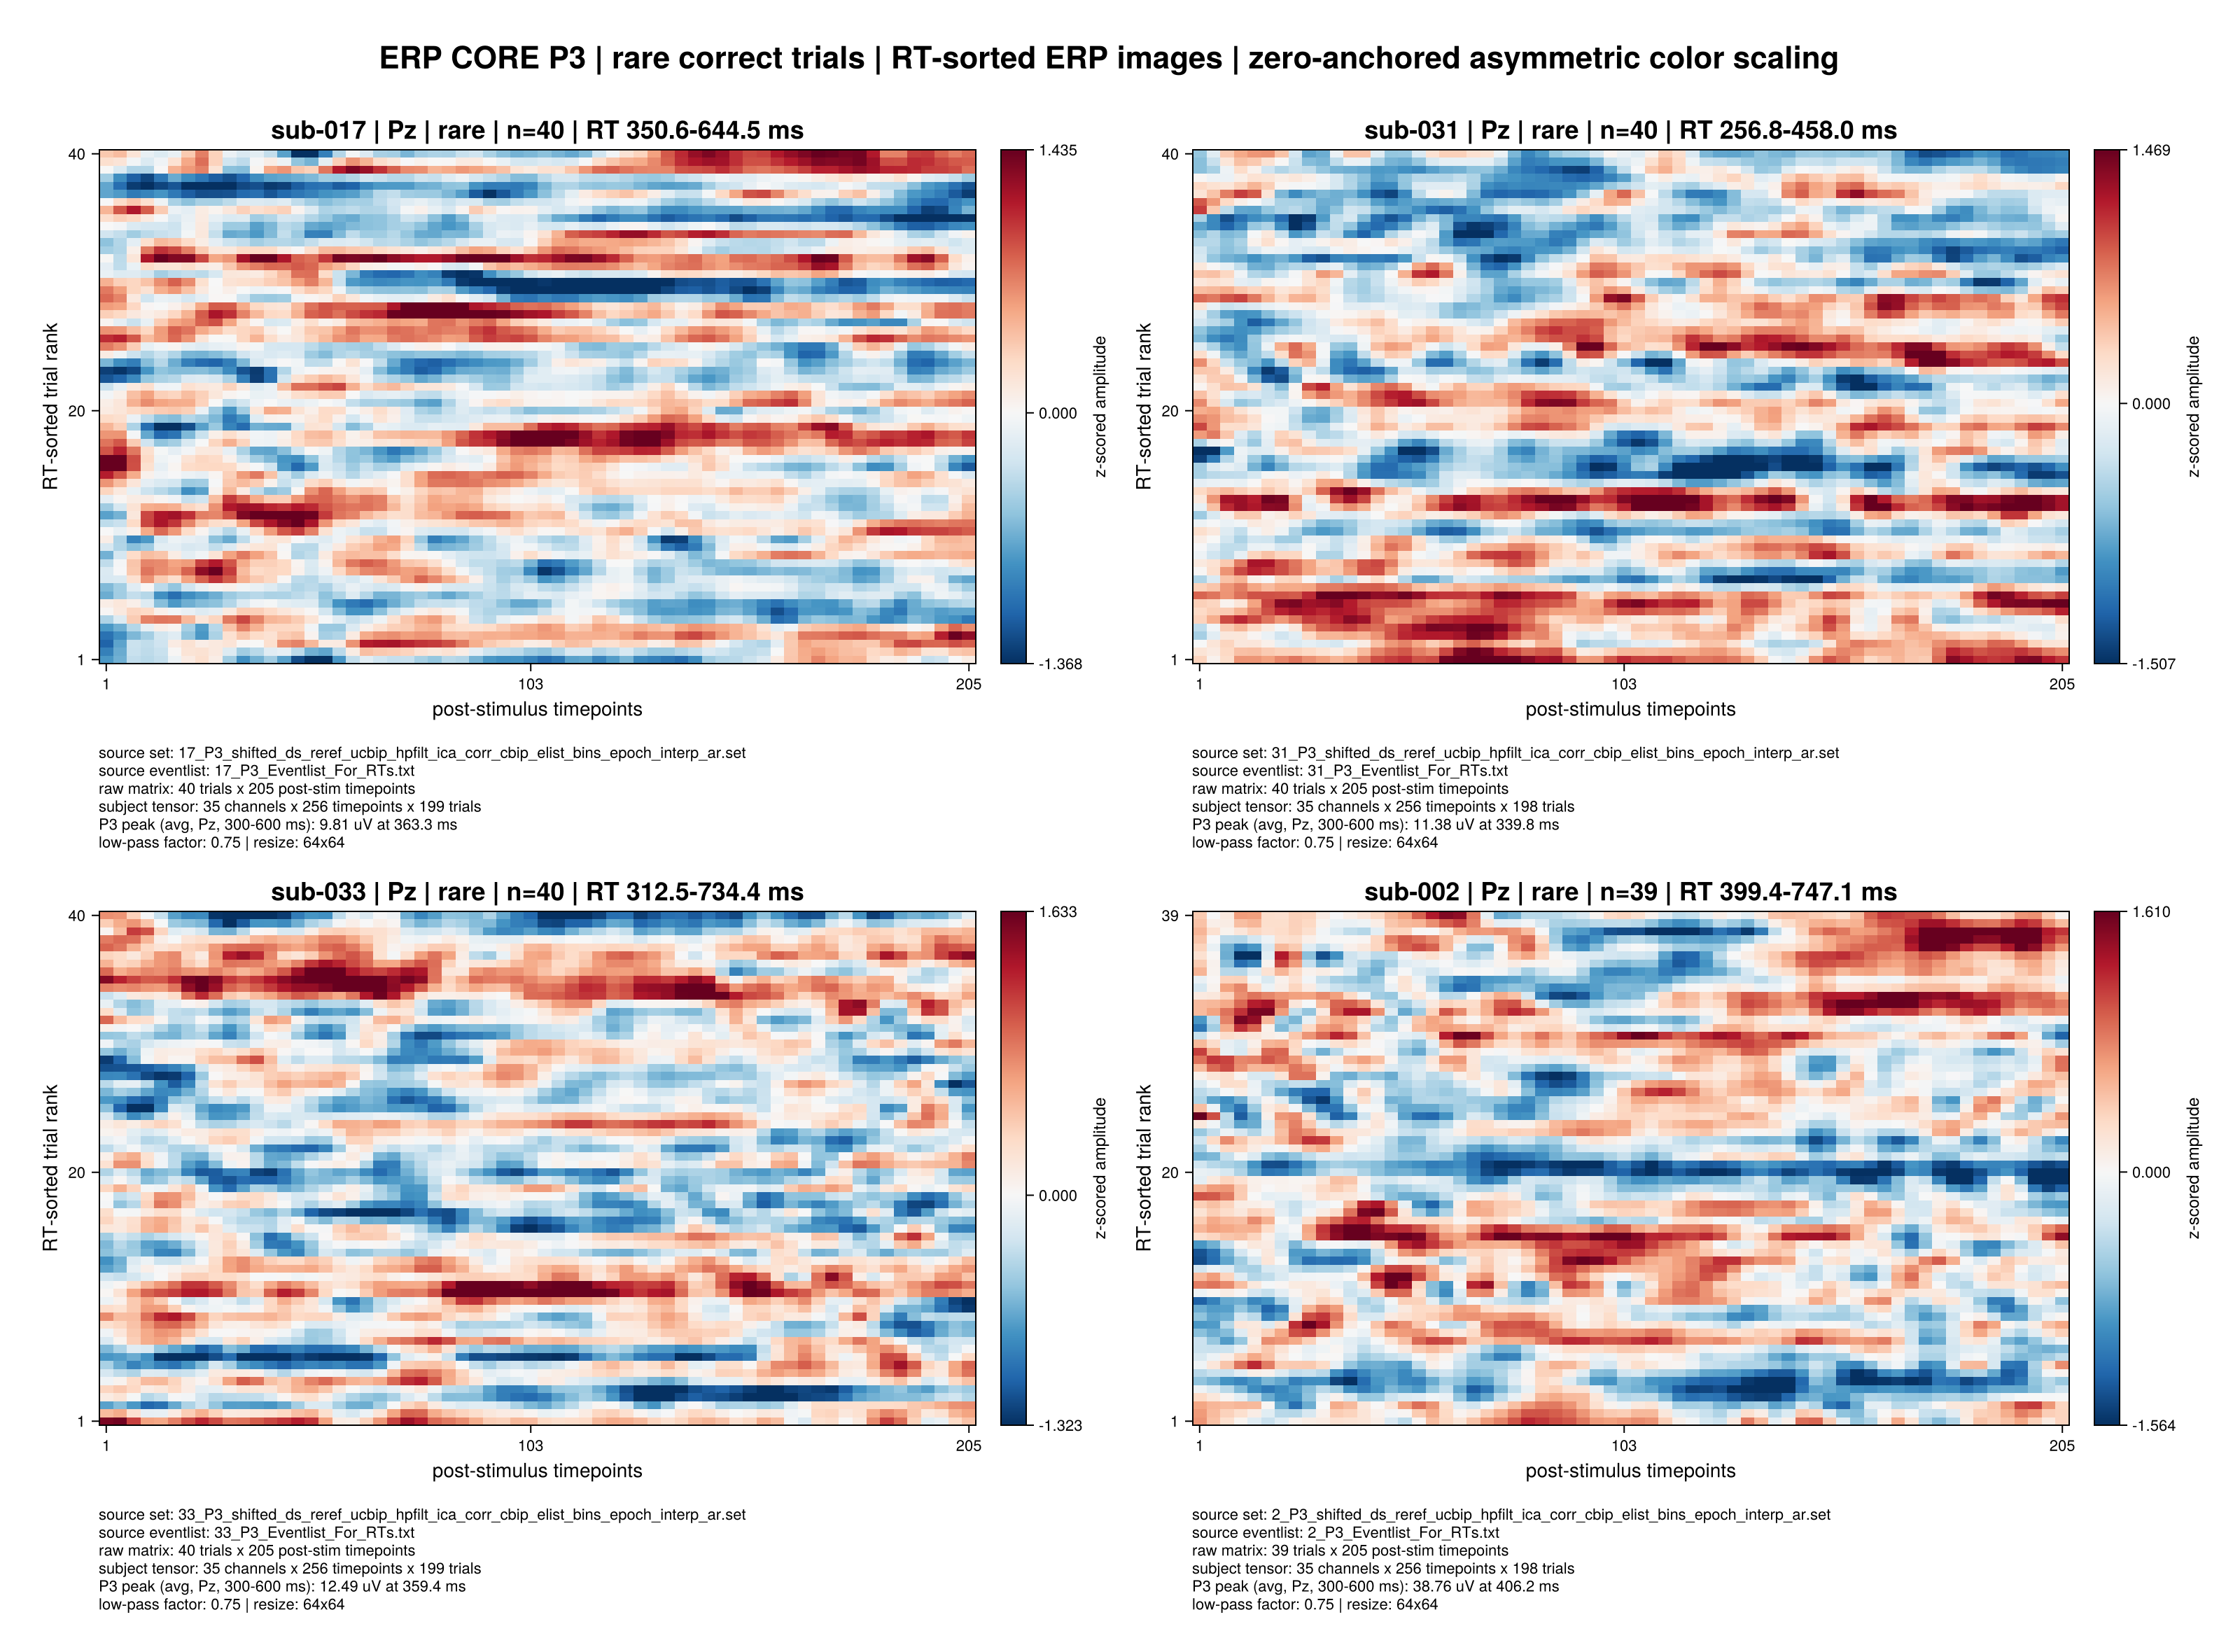

In [5]:
function time_ticks(sample)
    vals = [1, Int(cld(sample.resized_size[2], 2)), sample.resized_size[2]]
    labels = ["1", string(Int(cld(sample.n_timepoints_post, 2))), string(sample.n_timepoints_post)]
    return vals, labels
end

function trial_ticks(sample)
    vals = [1, Int(cld(sample.resized_size[1], 2)), sample.resized_size[1]]
    labels = ["1", string(Int(cld(sample.n_trials, 2))), string(sample.n_trials)]
    return vals, labels
end

function plot_rt_sorted_examples(samples)
    fig = Figure(size = (1600, 1180), figure_padding = 28)

    for (idx, sample) in enumerate(samples)
        row = fld(idx - 1, 2) + 1
        col = mod(idx - 1, 2) + 1

        panel = GridLayout(fig[row, col])
        rowgap!(panel, 10)
        colgap!(panel, 12)

        clipped, colorrange, tick_vals, tick_labels, cmap =
            clipped_color_stats_quantile_zero_ticks(sample.img_resized; q_low = 0.01, q_high = 0.99)
        plot_matrix = permutedims(clipped, (2, 1))

        xtick_vals, xtick_labels = time_ticks(sample)
        ytick_vals, ytick_labels = trial_ticks(sample)

        title = @sprintf(
            "%s | %s | %s | n=%d | RT %.1f-%.1f ms",
            sample.subject_label,
            sample.channel_name,
            sample.condition,
            sample.n_trials,
            sample.rt_min_ms,
            sample.rt_max_ms,
        )

        ax = Axis(
            panel[1, 1];
            title = title,
            titlesize = 18,
            xlabel = "post-stimulus timepoints",
            ylabel = "RT-sorted trial rank",
            xticks = (xtick_vals, xtick_labels),
            yticks = (ytick_vals, ytick_labels),
            xlabelsize = 14,
            ylabelsize = 14,
            xticklabelsize = 11,
            yticklabelsize = 11,
        )

        hm = heatmap!(ax, plot_matrix; colormap = cmap, colorrange = colorrange)

        Colorbar(
            panel[1, 2],
            hm;
            ticks = (tick_vals, tick_labels),
            width = 18,
            ticklabelsize = 11,
            label = "z-scored amplitude",
            labelsize = 12,
        )

        info = @sprintf(
            "source set: %s\nsource eventlist: %s\nraw matrix: %d trials x %d post-stim timepoints\nsubject tensor: %d channels x %d timepoints x %d trials\nP3 peak (avg, %s, %.0f-%.0f ms): %.2f uV at %.1f ms\nlow-pass factor: %.2f | resize: %dx%d",
            basename(sample.source_set_relpath),
            basename(sample.source_eventlist_relpath),
            sample.n_trials,
            sample.n_timepoints_post,
            sample.n_channels_total,
            sample.n_timepoints_total,
            sample.n_trials_total,
            sample.channel_name,
            P300_WINDOW_MS[1],
            P300_WINDOW_MS[2],
            sample.avg_peak_uv,
            sample.avg_peak_ms,
            LOWPASS_FACTOR,
            sample.resized_size[1],
            sample.resized_size[2],
        )

        Label(
            panel[2, 1:2],
            info;
            tellwidth = false,
            halign = :left,
            justification = :left,
            fontsize = 11,
        )
    end

    Label(
        fig[0, :],
        "ERP CORE P3 | rare correct trials | RT-sorted ERP images | zero-anchored asymmetric color scaling";
        fontsize = 22,
        font = :bold,
        padding = (0, 0, 10, 0),
    )

    return fig
end

fig = plot_rt_sorted_examples(sample_results)
fig
